You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import cv2
import os
import json

### Load dataframes

In [2]:
df_train = pd.read_csv("../../occlusion_datasets/train.csv", delimiter=',')
df_test = pd.read_csv("../../occlusion_datasets/test_students.csv", delimiter=',')

image_dir = "../../crops/Crop_224_5fp_100K"

In [3]:
df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [4]:
df_test.head()

,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [5]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [6]:
df_val = df_train.loc[:1000].reset_index()
df_train = df_train.loc[1000:].reset_index()

In [7]:
len(df_train), len(df_val), len(df_test)

(99000, 1001, 29980)

### Check that all images are read correctly

In [8]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)
        
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

100%|██████████| 29980/29980 [00:11<00:00, 2615.34it/s]


### Display random images

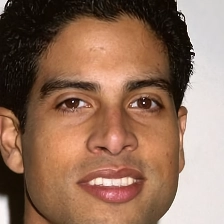

database1/img00003876.webp 0.038335 1.0


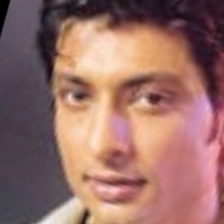

database3/database3/m.02685xh/92-FaceId-0_align.webp 0.047758 1.0


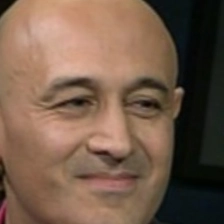

database3/database3/m.027bwr5/30-FaceId-0_align.webp 0.002423 1.0


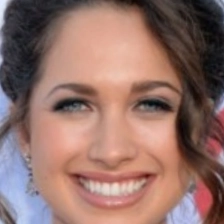

database3/database3/m.02799yc/43-FaceId-0_align.webp 0.082973 0.0


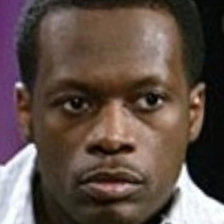

database3/database3/m.02gsbs/10-FaceId-0_align.webp 0.000362 1.0


In [8]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [9]:
class Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, df, image_dir, training=True):
         'Initialization'
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transforms.ToTensor()
         
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.df)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        row = self.df.loc[index]
        filename = row['filename']

        # Load data and get label
        img = Image.open(f"{image_dir}/{filename}")

        X = cv2.imread(f"{image_dir}/{filename}")

        if self.training:
            y = row['FaceOcclusion']
            y = np.float32(y)
            gender = row['gender']
            return X, y, gender, filename
        else:
            y = None
            gender = None
            return X, filename

In [10]:
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)
test_set = Dataset(df_test, image_dir, training=False)

params_train = {'batch_size': 1,
          'shuffle': True,
          'num_workers': 0}

params_val = {'batch_size': 1,
          'shuffle': False,
          'num_workers': 0}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

# Training-Free track

## Installation

In [11]:
from pathlib import Path
import subprocess
import sys

import gdown

### 3DDFA-V2

In [12]:
repo_dir = Path("3DDFA_V2")

if not repo_dir.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/cleardusk/3DDFA_V2.git"],
        check=True
    )

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", "3DDFA_V2/requirements.txt"],
        check=True
    )

    print("Repository cloné et dépendances installées.")
else:
    print("Repository déjà présent, installation ignorée.")

Repository déjà présent, installation ignorée.


### BiSeNet

In [13]:
repo_dir = Path("face-parsing.PyTorch")

if not repo_dir.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/zllrunning/face-parsing.PyTorch.git"],
        check=True
    )

    print("Repository cloné.")
else:
    print("Repository déjà présent, installation ignorée.")

Repository déjà présent, installation ignorée.


Le modèle pré-entrainé n'est pas directement accessible depuis le repo Git, mais depuis un Drive. Voici les informations pour le récupérer en cas d'échec du téléchargement automatique.

Lien pour la copie des poids : https://drive.google.com/open?id=154JgKpzCPW82qINcVieuPH3fZ2e0P812
A placer dans un sous-dossier weights, à partir du dossier courant du notebook

In [14]:
Path("weights").mkdir(exist_ok=True)

file_id = "154JgKpzCPW82qINcVieuPH3fZ2e0P812"
output = "weights/79999_iter.pth"

if not Path(output).exists():
    gdown.download(
        f"https://drive.google.com/uc?id={file_id}",
        output,
        quiet=False
    )
    print("Modèle chargé")
else:
    print("Modèle déjà installé")

Modèle déjà installé


## Model Imports

In [15]:
#Face Analysis

from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name='buffalo_l',
    providers=[
        'CPUExecutionProvider'
    ]
)
app.prepare(
    ctx_id=0,
    det_size=(224, 224)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3,

In [16]:
# 3DDFA-V2

ROOT = Path.cwd()
THREEDDFA_PATH = ROOT / "3DDFA_V2"
sys.path.append(str(THREEDDFA_PATH))
print(THREEDDFA_PATH)

from TDDFA import TDDFA

MODEL_PATH = Path.cwd() / "3DDFA_V2" / "weights" / "mb1_120x120.pth"

cfg = {
    'arch': 'mobilenet',
    'checkpoint_fp': str(MODEL_PATH),
    'gpu_mode': False
}

tddfa = TDDFA(**cfg)

from utils.pose import viz_pose

/Users/julienniol/Documents/MS IA/IAD704 - DeepLearning/Data_Challenge/DataChallenge2026/data-challenge-42/notebooks/3DDFA_V2


In [17]:
#BiSeNet

BISENET_PATH = ROOT / "face-parsing.PyTorch"
sys.path.append(str(BISENET_PATH))

from model import BiSeNet
import torch

WEIGHTS = (
    Path.cwd()
    / "weights"
    / "79999_iter.pth"
)

assert WEIGHTS.exists()

n_classes = 19
net = BiSeNet(n_classes=n_classes)
net.load_state_dict(
    torch.load(
        WEIGHTS,
        map_location="cpu"
    )
)

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
net.eval().to(device)

BiSeNet(
  (cp): ContextPath(
    (resnet): Resnet18(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm

In [18]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

seg_processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
seg_model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
seg_model.to(device)

/Users/julienniol/Documents/MS IA/IAD704 - DeepLearning/Data_Challenge/DataChallenge2026/data-challenge-42/venv_42/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 10359.23it/s]


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_features=64, out_features=64, bias=True)
              (k_proj): Linear(in_features=64, out_features=64, bias=True)
              (v_proj): Linear(in_features=64, out_features=64, bias=True)
              (o_proj): Linear(in_features=64, out_features=64, bias=True)
              (sequence_reduction): SegformerSequenceReduction(
                (sequence_reduction): Conv2d(64, 64, kernel_size=(8, 8), s

## Pipeline and configuration

In [ ]:
from torchvision import transforms

# Segmentation classes for BiSeNet and SegFormer

VISIBLE_FACE_CLASSES_B = [
    0,   # background (in case of missed detection)
    1,   # skin
    2,   # left eyebrow
    3,   # right eyebrow
    4,   # left eye
    5,   # right eye
    6,   # eyeglasses
    10,  # nose
    11,  # mouth
    12,  # upper lip
    13  # lower lip
]

VISIBLE_FACE_CLASSES_S = [
    1,   # skin
    2,  # nose
    3,   # eyeglasses
    4,   # left eye
    5,   # right eye
    6,   # left eyebrow
    7,   # right eyebrow
    10,  # mouth
    11,  # upper lip
    12  # lower lip
]

HAIR_B = [17]
HAT_B = [18]
HAIR_S = [13]
HAT_S = [14]

# === Constantes pour la detection des erreurs de segmentation (stratégie fallback) ===
SKIN_ONLY_B = [1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13]
SKIN_ONLY_S = [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12]
BG_B        = [0]

BI_ERROR_THRESHOLD = 0.7
SF_ERROR_THRESHOLD = 0.3

# Transformation in tensor
to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    ),
])

In [20]:
def overlay_mask(image,mask,color,alpha=0.4):
    '''
    Superimposing semgented mask on initial image for visualization
    '''
    overlay = image.copy()
    overlay[mask > 0] = color
    blended = cv2.addWeighted(
        overlay,
        alpha,
        image,
        1 - alpha,
        0
    )
    return blended

In [21]:
# === Sous-fonction 1 : detection visage + genre (InsightFace) ===
def detect_face_and_gender(app, img):
    """Detecte le visage principal dans l'image avec InsightFace.

    Args:
        app: instance FaceAnalysis InsightFace
        img: numpy array BGR

    Returns:
        (face_bbox, pred_gender) ou (None, None) si aucun visage detecte.
        pred_gender est 'F' ou 'M' (sortie face.sex).
    """
    faces = app.get(img)
    if not faces:
        return None, None
    face = faces[0]
    return face.bbox, face.sex


In [22]:
# === Sous-fonction 2 : calcul du mask theorique (3DDFA-V2 + correction Julien) ===
def compute_theoretical_face_mask(tddfa, img, bbox):
    """Calcule le mask theorique du visage par reconstruction 3D et applique la
    correction empirique de Julien (scale_x=0.9, scale_y=1.05, tx=15, ty=-10).

    Args:
        tddfa: instance TDDFA
        img: numpy array BGR
        bbox: face bbox (sortie InsightFace)

    Returns:
        (mask_theoretical, total_pixels) : matrice HxW uint8 et nombre total de pixels du mask.
    """
    # Reconstruction 3D du visage
    param_lst, roi_box_lst = tddfa(img, [bbox])
    ver_lst = tddfa.recon_vers(param_lst, roi_box_lst, dense_flag=True)

    # Convex hull des vertices projetes -> mask 2D
    mask_theoretical = np.zeros(img.shape[:2], dtype=np.uint8)
    pts = ver_lst[0][:2, :].T.astype(np.int32)
    cv2.fillConvexPoly(mask_theoretical, cv2.convexHull(pts), 1)

    # Correction empirique de Julien
    scale_x = 0.9
    scale_y = 1.05
    tx = 15
    ty = -10
    M = np.array([[scale_x, 0, tx], [0, scale_y, ty]], dtype=np.float32)
    mask_theoretical = cv2.warpAffine(mask_theoretical, M, dsize=img.shape[:2])

    return mask_theoretical, float(np.sum(mask_theoretical))

In [23]:
# === Sous-fonction 3 : segmentation BiSeNet ===
def segment_with_bisenet(net, to_tensor, img, device='cpu'):
    """Run BiSeNet face parsing sur l'image et retourne le parsing argmax.

    Args:
        net: modele BiSeNet
        to_tensor: torchvision transforms compose (ToTensor + Normalize)
        img: numpy array BGR (sera converti automatiquement par to_tensor)
        device: 'cpu' ou 'cuda'

    Returns:
        parsing: numpy array HxW d'entiers (indices de classe 0-18 pour BiSeNet)
    """
    input_tensor = to_tensor(img).unsqueeze(0).to(device)
    out = net(input_tensor)[0]
    return out.squeeze(0).cpu().numpy().argmax(0)

In [24]:
# === Sous-fonction 4 : segmentation SegFormer ===
def segment_with_segformer(seg_model, seg_processor, img, device='cpu'):
    """Run SegFormer face parsing sur l'image et retourne le parsing argmax.

    Args:
        seg_model: modele SegFormer (transformers SegformerForSemanticSegmentation)
        seg_processor: SegformerImageProcessor associe
        img: numpy array BGR
        device: 'cpu' ou 'cuda'

    Returns:
        parsing: numpy array HxW d'entiers (indices de classe 0-18 pour SegFormer)
    """
    inputs = seg_processor(images=img, return_tensors="pt").to(device)
    outputs = seg_model(**inputs)
    # Upsample les logits a la taille de l'image originale
    h, w = img.shape[:2]
    upsampled = nn.functional.interpolate(
        outputs.logits, size=(h, w), mode='bilinear', align_corners=False
    )
    return upsampled.argmax(dim=1)[0].cpu().numpy()

In [25]:
# === Sous-fonction 5 : calcul generique des ratios hair/hat/other ===
def compute_ratios_from_parsing(parsing, mask_theoretical, total_pixels,
                                 VISIBLE_CLASSES, HAIR_CLASSES, HAT_CLASSES):
    """Calcule (hair_ratio, hat_ratio, other_ratio) a partir d'un parsing.

    Generique : fonctionne pour BiSeNet ou SegFormer en passant les bonnes listes
    de classes.

    Args:
        parsing: numpy array HxW d'indices de classe
        mask_theoretical: numpy array HxW (uint8 0/1) du mask
        total_pixels: nombre total de pixels du mask (float)
        VISIBLE_CLASSES: liste des classes 'visibles' (sera filtree)
        HAIR_CLASSES: liste des classes 'cheveux' (typiquement [17] BiSeNet, [13] SegFormer)
        HAT_CLASSES: liste des classes 'chapeau' (typiquement [18] BiSeNet, [14] SegFormer)

    Returns:
        (hair_ratio, hat_ratio, other_ratio) : 3 floats dont la somme + visible_ratio = 1.0
    """
    # Masks binaires par categorie
    visible_mask = np.isin(parsing, VISIBLE_CLASSES).astype(np.uint8)
    hair_mask = np.isin(parsing, HAIR_CLASSES).astype(np.uint8)
    hat_mask = np.isin(parsing, HAT_CLASSES).astype(np.uint8)

    # Pixels par categorie dans le mask theorique
    visible_pixels = float(np.sum(visible_mask & mask_theoretical))
    hair_pixels    = float(np.sum(hair_mask    & mask_theoretical))
    hat_pixels     = float(np.sum(hat_mask     & mask_theoretical))
    # Other = total - (visible + hair + hat). Conventionnellement clip a 0.
    other_pixels = max(0.0, total_pixels - visible_pixels - hair_pixels - hat_pixels)

    return (
        hair_pixels / total_pixels,
        hat_pixels / total_pixels,
        other_pixels / total_pixels,
        visible_pixels / total_pixels,
    )

In [54]:
# === Sous-fonction 6 : calcul des 3 features pour detection plante v2 ===
def compute_fallback_features(parsing_b, parsing_s, mask_theoretical, total_pixels):
    """Calcule les 3 features supplementaires necessaires au fallback v2.

    Ces features sont independantes de la formule principale et servent uniquement
    a detecter quand BiSeNet ou SegFormer plante.

    Args:
        parsing_b: parsing BiSeNet (sortie de segment_with_bisenet)
        parsing_s: parsing SegFormer (sortie de segment_with_segformer)
        mask_theoretical: mask theorique (sortie de compute_theoretical_face_mask)
        total_pixels: nombre total de pixels du mask

    Returns:
        (skin_only_b_ratio, bg_b_ratio, skin_only_s_ratio) : 3 floats dans [0, 1]
    """
    skin_only_b = np.isin(parsing_b, SKIN_ONLY_B).astype(np.uint8)
    bg_b        = np.isin(parsing_b, BG_B).astype(np.uint8)
    skin_only_s = np.isin(parsing_s, SKIN_ONLY_S).astype(np.uint8)
    return (
        float(np.sum(skin_only_b & mask_theoretical)) / total_pixels,
        float(np.sum(bg_b        & mask_theoretical)) / total_pixels,
        float(np.sum(skin_only_s & mask_theoretical)) / total_pixels,
    )

In [53]:
def compute_occlusion_score(pred_gender,visible_pixels_ratio_b,visible_pixels_ratio_s,hair_ratio_b,hair_ratio_s,hat_ratio_b,hat_ratio_s,other_ratio_b,other_ratio_s,mode="test",opt="None"):

    ### Occlusion score
    occlusion_score_b = 1.0 - visible_pixels_ratio_b
    occlusion_score_s = 1.0 - visible_pixels_ratio_s   

    if mode=="test" and opt!="None":
        if opt == "OLS":
            # Loading weights pre-computed
            with open("weights.json", "r", encoding="utf-8") as f:
                weights = json.load(f)
            F_WEIGHTS = weights["female"]
            M_WEIGHTS = weights["male"]
            if pred_gender == 'M':
                if hair_ratio_b >= 0.1:
                    occlusion_score_b = np.clip(M_WEIGHTS["hair_bi"][0] * occlusion_score_b + M_WEIGHTS["hair_bi"][1],0,1)
                elif hat_ratio_b >= 0.1:
                    occlusion_score_b = np.clip(M_WEIGHTS["hat_bi"][0] * occlusion_score_b + M_WEIGHTS["hat_bi"][1],0,1)
                else:
                    occlusion_score_b = np.clip(M_WEIGHTS["other_bi"][0] * occlusion_score_b + M_WEIGHTS["other_bi"][1],0,1)

                if hair_ratio_s >= 0.1:
                    occlusion_score_s = np.clip(M_WEIGHTS["hair_sf"][0] * occlusion_score_s + M_WEIGHTS["hair_sf"][1],0,1)
                elif hat_ratio_s >= 0.1:
                    occlusion_score_s = np.clip(M_WEIGHTS["hat_sf"][0] * occlusion_score_s + M_WEIGHTS["hat_sf"][1],0,1)
                else:
                    occlusion_score_s = np.clip(M_WEIGHTS["other_sf"][0] * occlusion_score_s + M_WEIGHTS["other_sf"][1],0,1)        
            elif pred_gender == 'F':
                if hair_ratio_b >= 0.1:
                    occlusion_score_b = np.clip(F_WEIGHTS["hair_bi"][0] * occlusion_score_b + F_WEIGHTS["hair_bi"][1],0,1)
                elif hat_ratio_b >= 0.1:
                    occlusion_score_b = np.clip(F_WEIGHTS["hat_bi"][0] * occlusion_score_b + F_WEIGHTS["hat_bi"][1],0,1)
                else:
                    occlusion_score_b = np.clip(F_WEIGHTS["other_bi"][0] * occlusion_score_b + F_WEIGHTS["other_bi"][1],0,1)

                if hair_ratio_s >= 0.1:
                    occlusion_score_s = np.clip(F_WEIGHTS["hair_sf"][0] * occlusion_score_s + F_WEIGHTS["hair_sf"][1],0,1)
                elif hat_ratio_s >= 0.1:
                    occlusion_score_s = np.clip(F_WEIGHTS["hat_sf"][0] * occlusion_score_s + F_WEIGHTS["hat_sf"][1],0,1)
                else:
                    occlusion_score_s = np.clip(F_WEIGHTS["other_sf"][0] * occlusion_score_s + F_WEIGHTS["other_sf"][1],0,1) 
        if opt=="NM":
            # Loading weights pre-computed
            with open("coeffs.json", "r", encoding="utf-8") as f:
                weights = json.load(f)
            F_WEIGHTS = weights["female"]
            M_WEIGHTS = weights["male"]
            if pred_gender == 'M':
                occlusion_score_b = np.clip(M_WEIGHTS["hair_bi"] * hair_ratio_b + M_WEIGHTS["hat_bi"] * hat_ratio_b + M_WEIGHTS["other_bi"] * other_ratio_b,0,1) 
                occlusion_score_s = np.clip(M_WEIGHTS["hair_sf"] * hair_ratio_s + M_WEIGHTS["hat_sf"] * hat_ratio_s + M_WEIGHTS["other_sf"] * other_ratio_s,0,1)        
            elif pred_gender == 'F':
                occlusion_score_b = np.clip(F_WEIGHTS["hair_bi"] * hair_ratio_b + F_WEIGHTS["hat_bi"] * hat_ratio_b + F_WEIGHTS["other_bi"] * other_ratio_b,0,1) 
                occlusion_score_s = np.clip(F_WEIGHTS["hair_sf"] * hair_ratio_s + F_WEIGHTS["hat_sf"] * hat_ratio_s + F_WEIGHTS["other_sf"] * other_ratio_s,0,1)  

    return occlusion_score_b, occlusion_score_s

In [28]:
DEFAULT_DAMPENING_THRESHOLD = 0.35
DEFAULT_DAMPENING_SLOPE = 0.5


def damp(x, threshold, slope):
    """Piecewise linear : identite en dessous du seuil, pente reduite au-dessus."""
    if x < threshold:
        return x
    return threshold + slope * (x - threshold)

In [29]:
def apply_dampening(hair_ratio_b, hat_ratio_b,
                        hair_ratio_s, hat_ratio_s,
                        dampening_threshold=DEFAULT_DAMPENING_THRESHOLD,
                        dampening_slope=DEFAULT_DAMPENING_SLOPE):
    """Variante de apply_v2_fallback qui ajoute un dampening sur hair et hat.

    Mecanique identique a apply_v2_fallback (meme detection plante, meme fallback)
    SAUF que hair_ratio_b, hair_ratio_s, hat_ratio_b, hat_ratio_s sont dampes
    avant utilisation dans la formule. other_ratio_b et other_ratio_s NE SONT PAS
    dampes (pas de pattern de sur-pred observe dessus).

    Args:
        ... (identiques a apply_v2_fallback) ...
        dampening_threshold (float, default 0.35) : seuil au-dessus duquel la pente
            est reduite. En dessous, comportement lineaire identique a apply_v2_fallback.
        dampening_slope (float, default 0.5) : pente au-dessus du seuil. Mettre 1.0
            pour desactiver le dampening (revient a apply_v2_fallback).

    Returns:
        float : occlusion score clip entre 0 et 1.
    """
    # Damp hair et hat (BiSeNet et SegFormer). other_b et other_s INCHANGES.
    hair_b_d = damp(hair_ratio_b, dampening_threshold, dampening_slope)
    hat_b_d  = damp(hat_ratio_b,  dampening_threshold, dampening_slope)
    hair_s_d = damp(hair_ratio_s, dampening_threshold, dampening_slope)
    hat_s_d  = damp(hat_ratio_s,  dampening_threshold, dampening_slope)

    # Le reste : identique a apply_v2_fallback mais avec features dampees
    return hair_b_d, hat_b_d, hair_s_d, hat_s_d

In [51]:
def apply_fallback(occlusion_score_b,occlusion_score_s,bg_b_ratio, skin_only_s_ratio,opt="None"):
    """Calcule le score d'occlusion avec gestion automatique des plantages.

    Cette fonction remplace le bloc `if pred_gender == 'M' / elif 'F'` du notebook.
    Elle se comporte EXACTEMENT comme la formule actuelle quand aucun modele ne
    plante (cas normal, ~98% des images). Quand un modele plante, elle bascule
    intelligemment sur l'autre.

    Args:
        pred_gender (str): 'M' ou 'F', sortie de face.sex (InsightFace).
        hair_ratio_b, hat_ratio_b, other_ratio_b (float): ratios BiSeNet de Julien.
        hair_ratio_s, hat_ratio_s, other_ratio_s (float): ratios SegFormer de Julien.
        skin_only_b_ratio (float): NOUVEAU. Fraction de skin pur (sans bg, sans eye_g,
                                   avec ears) detectee par BiSeNet dans le mask.
                                   Utilise pour diagnostic/debug, pas dans la decision.
        bg_b_ratio (float):        NOUVEAU. Fraction de background detectee par BiSeNet
                                   dans le mask. Si > 0.70 -> BiSeNet plante.
        skin_only_s_ratio (float): NOUVEAU. Fraction de skin pur (sans bg, sans eye_g,
                                   avec ears) detectee par SegFormer dans le mask.
                                   Si < 0.30 -> SegFormer plante.
        M_WEIGHTS, F_WEIGHTS (dict): tes coefficients du notebook (inchanges).

    Returns:
        float: score d'occlusion clip entre 0 et 1 (= ton ancien occlusion_score).
    """

    # ------ ETAPE 2 : detection plantage (independante du genre) ------
    # bg_b_ratio > 0.70 : BiSeNet a etiquette ~tout le visage en background
    # skin_only_s_ratio < 0.30 : SegFormer ne voit quasi aucune peau
    bisenet_error = bg_b_ratio > BI_ERROR_THRESHOLD
    segformer_error = skin_only_s_ratio < SF_ERROR_THRESHOLD

    # ------ ETAPE 3 : choix de la formule ------
    if segformer_error and not bisenet_error:
        # CAS 1 : SegFormer plante mais BiSeNet OK
        # -> on calcule pred avec UNIQUEMENT la moitie BiSeNet (3 termes au lieu de 6)
        # -> on ignore les ratios SegFormer (ils sont absurdes : other_ratio_s ~ 0.95)
        score = occlusion_score_b

    elif bisenet_error and not segformer_error:
        # CAS 2 : BiSeNet plante mais SegFormer OK
        # -> on calcule pred avec UNIQUEMENT la moitie SegFormer
        # -> on ignore les ratios BiSeNet
        score = occlusion_score_s

    elif bisenet_error and segformer_error:
        # CAS 3 : les 2 plantent -> on prend "le moins pire"
        # On mesure le degre de plantage de chaque modele (haut = plus plante) :
        #   - BiSeNet : bg_b_ratio (plus c'est haut, plus BiSeNet a sature en bg)
        #   - SegFormer : 1 - skin_only_s_ratio (plus c'est haut, moins SegFormer voit de peau)
        # On bascule sur le modele dont le score de plantage est le plus bas.
        error_score_bisenet = bg_b_ratio
        error_score_segformer = 1.0 - skin_only_s_ratio
        if error_score_bisenet < error_score_segformer:
            # BiSeNet est "moins pire" -> sa contribution est plus fiable
            score = occlusion_score_b
        else:
            # SegFormer est "moins pire" -> sa contribution est plus fiable
            score = occlusion_score_s

    else:
        # CAS 4 (le plus frequent, ~98% des images) : aucun modele ne plante
        # -> on utilise la formule complete habituelle, identique a ton notebook
        if opt=="NM":
            score = occlusion_score_b+occlusion_score_s
        else:
            score = 0.5*occlusion_score_b + 0.5*occlusion_score_s
        
    # ------ ETAPE 4 : clip final entre 0 et 1 (identique a ton notebook) ------
    return score


In [50]:
# === Orchestrateur : occlusion_computation (appelle toutes les sous-fonctions) ===
def occlusion_computation(app, img, display_results=False, mode="test",opt="None"):
    """Pipeline complete : detecte le visage, segmente, calcule les ratios,
    applique le v2 fallback + dampening, retourne le score d'occlusion.

    Signature compatible avec les cellules suivantes du notebook qui appellent
    occlusion_computation(app, img) pour la generation des resultats val / test.

    Args:
        app: instance FaceAnalysis InsightFace
        img: numpy array BGR
        display_results: si True, affiche les overlays (debug visuel)

    Returns:
        occlusion_score : float dans [0, 1] (= ton ancien y_pred)
    """
    # Resize unique a 512x512 pour unifier le pipeline (logique Julien)
    img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_CUBIC)

    # === Etape 1 : detection visage + genre ===
    bbox, pred_gender = detect_face_and_gender(app, img)
    if bbox is None:
        if mode=="val":
            return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        else:
            return 0.0

    # === Etape 2 : mask theorique 3D avec correction Julien ===
    mask_theoretical, total_pixels = compute_theoretical_face_mask(tddfa, img, bbox)
    if total_pixels == 0:
        return 0.0

    # === Etape 3 : segmentations BiSeNet + SegFormer ===
    parsing_b = segment_with_bisenet(net, to_tensor, img, device=device)
    parsing_s = segment_with_segformer(seg_model, seg_processor, img, device=device)

    # === Etape 4 : ratios hair/hat/other/visible pour chaque modele ===
    hair_ratio_b, hat_ratio_b, other_ratio_b, visible_pixels_ratio_b = compute_ratios_from_parsing(
        parsing_b, mask_theoretical, total_pixels,
        VISIBLE_FACE_CLASSES_B, HAIR_B, HAT_B,
    )
    hair_ratio_s, hat_ratio_s, other_ratio_s, visible_pixels_ratio_s = compute_ratios_from_parsing(
        parsing_s, mask_theoretical, total_pixels,
        VISIBLE_FACE_CLASSES_S, HAIR_S, HAT_S,
    )

    # === Etape 5 : features de detection d'erreur segmentation (pour le fallback) ===
    skin_only_b_ratio, bg_b_ratio, skin_only_s_ratio = compute_fallback_features(
        parsing_b, parsing_s, mask_theoretical, total_pixels,
    )

    # === Etape 6 : dampening ===
    hair_ratio_bd, hat_ratio_bd, hair_ratio_sd, hat_ratio_sd = apply_dampening(hair_ratio_b, hat_ratio_b, hair_ratio_s, hat_ratio_s)

    # === Etape 7 : occlusion score ===
    occlusion_score_b, occlusion_score_s = compute_occlusion_score(pred_gender,visible_pixels_ratio_b,visible_pixels_ratio_s,hair_ratio_bd,hair_ratio_sd,hat_ratio_bd,hat_ratio_sd,other_ratio_b,other_ratio_s,mode,opt)

    # === Etape 8 : calcul du score avec fallback ===
    occlusion_score = apply_fallback(occlusion_score_b,occlusion_score_s,bg_b_ratio, skin_only_s_ratio,opt)

    # === Visualisation optionnelle (debug) ===
    if display_results:
        visible_skin_mask_b = np.isin(parsing_b, VISIBLE_FACE_CLASSES_B).astype(np.uint8)
        visible_skin_mask_s = np.isin(parsing_s, VISIBLE_FACE_CLASSES_S).astype(np.uint8)
        vis1 = overlay_mask(img, mask_theoretical, color=(0, 255, 0), alpha=0.35)
        vis2 = overlay_mask(vis1, visible_skin_mask_b, color=(255, 0, 0), alpha=0.35)
        vis3 = overlay_mask(vis2, visible_skin_mask_s, color=(255, 0, 0), alpha=0.35)
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(vis3, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(
            f"{filename}\n"
            f"GT occlusion={occlusion:.3f} | {gender} - {pred_gender} | Pred occlusion={occlusion_score:.3f}"
        )
        plt.show()

    if mode=="val":
        return occlusion_score, occlusion_score_b, occlusion_score_s, hair_ratio_bd, hair_ratio_sd, hat_ratio_bd, hat_ratio_sd, other_ratio_b, other_ratio_s
    else:
        return occlusion_score


## Load random image and apply pipeline

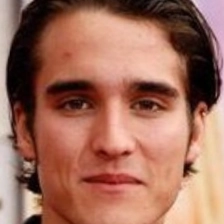

database3/database3/m.027_y8g/56-FaceId-0_align.webp 0.022985 1.0


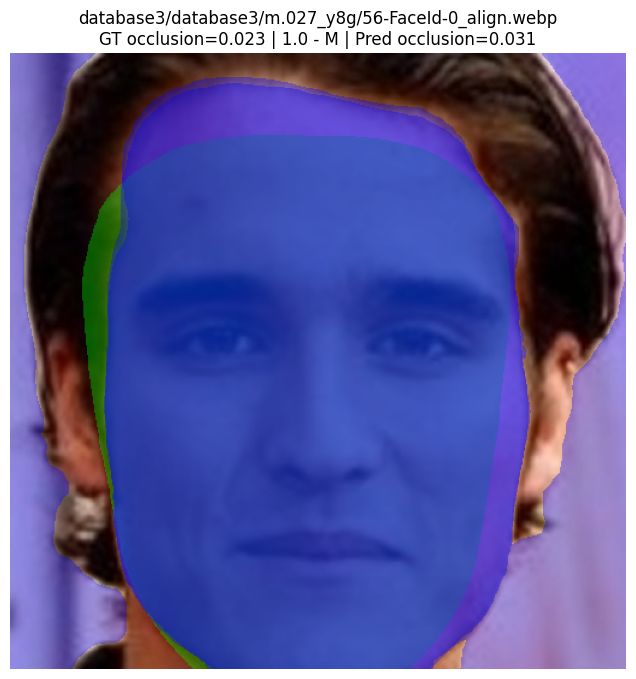

Score :0.031


In [155]:
for idx, row in df_train.sample(frac=1)[:1].iterrows():
   filename = row['filename']
   occlusion = row['FaceOcclusion']
   gender = row['gender']
   img2display = Image.open(f"{image_dir}/{filename}")
   display(img2display)
   print(filename, occlusion, gender)

img = cv2.imread(f"{image_dir}/{filename}")

#occlusion_score, occlusion_score_b, occlusion_score_s, hair_ratio_b, hair_ratio_s, hat_ratio_b, hat_ratio_s, other_ratio_b, other_ratio_s = occlusion_computation(app,img,display_results=True,mode="val")
occlusion_score = occlusion_computation(app,img,display_results=True,mode="test",opt="NM")

print(f"Score :{occlusion_score:.3f}")

## Generate results on validation dataset

In [35]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [36]:
results_list = []
for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
    for i in range(len(X)):
        img = cv2.imread(os.path.join(image_dir, filename[i]))
        y_pred, occlusion_score_b, occlusion_score_s, hair_ratio_b, hair_ratio_s, hat_ratio_b, hat_ratio_s, other_ratio_b, other_ratio_s = occlusion_computation(app,img,mode="val")
        results_list.append({'filename': filename[i],
                                'pred': float(y_pred),
                                'target': float(y[i]),
                                'gender': float(gender[i]),
                                'error' : float(torch.abs(y_pred-y[i])),
                                'score_b' : float(occlusion_score_b),
                                'score_s' : float(occlusion_score_s),
                                'hair_b' : float(hair_ratio_b),
                                'hair_s' : float(hair_ratio_s),
                                'hat_b' : float(hat_ratio_b),
                                'hat_s' : float(hat_ratio_s),
                                'other_b' : float(other_ratio_b),
                                'other_s' : float(other_ratio_s),                                
                                })
results_df = pd.DataFrame(results_list)

100%|██████████| 1001/1001 [03:15<00:00,  5.11it/s]


In [73]:
results_list = []
for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
    for i in range(len(X)):
        img = cv2.imread(os.path.join(image_dir, filename[i]))
        y_pred = occlusion_computation(app,img,mode="test",opt="NM")
        results_list.append({'filename': filename[i],
                                'pred': float(y_pred),
                                'target': float(y[i]),
                                'gender': float(gender[i]),
                                'error' : float(torch.abs(y_pred-y[i])),
                                })
results_df = pd.DataFrame(results_list)

100%|██████████| 1001/1001 [03:10<00:00,  5.26it/s]


In [74]:
results_df.head()

,filename,pred,target,gender,error
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.032221,0.024005,1.0,0.008216
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.054653,0.030028,1.0,0.024625
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.047337,0.009984,0.0,0.037353
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.328381,0.255016,1.0,0.073365
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.247309,0.252091,1.0,0.004782


<Axes: >

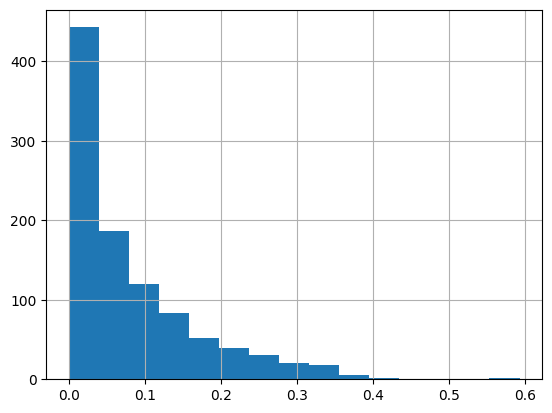

In [75]:
import matplotlib.pyplot as plt
results_df['target'].hist(bins=15)

<Axes: >

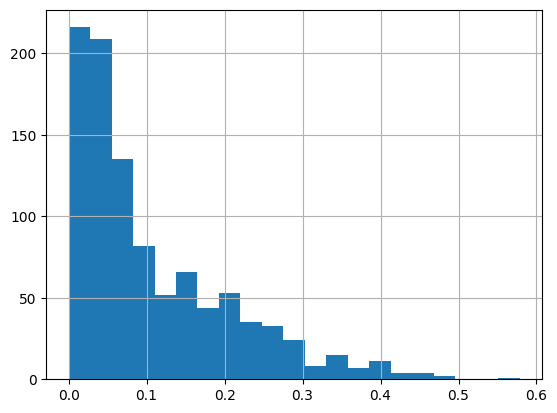

In [76]:
import matplotlib.pyplot as plt
results_df['pred'].hist(bins=21)

In [77]:
results_df['bin'] = np.floor(results_df['target']*20)
error_df = results_df[['bin','error','gender']]

In [78]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [79]:
er_m = error_fn(results_df)
print(f"Error Metric : {er_m:.5f}")

Error Metric : 0.00522


In [80]:
fn_m = metric_fn(results_male, results_female)
print(f"Fairness Metric : {fn_m:.5f}")

Fairness Metric : 0.00684


In [81]:
mae = error_df.groupby(['bin'])['error'].mean()
mae_fm = error_df.groupby(['bin','gender'])['error'].mean().reset_index()
mae_male = mae_fm.loc[mae_fm["gender"] == 1.0]
mae_female = mae_fm.loc[mae_fm["gender"] == 0.0]

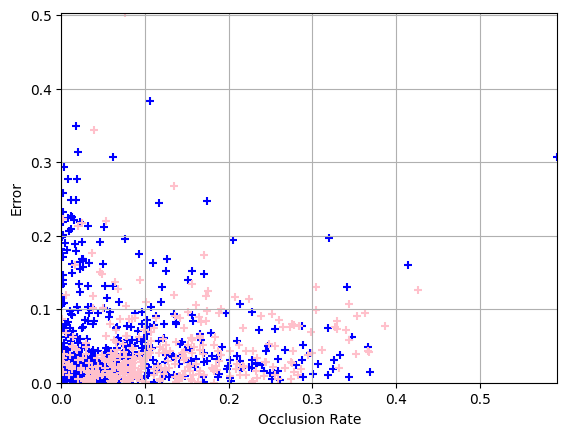

In [82]:
plt.scatter(x=results_male['target'],y=results_male['error'], marker='+', label="predicted error", c='blue')
plt.scatter(x=results_female['target'],y=results_female['error'], marker='+', label="predicted error", c='pink')
plt.xlabel("Occlusion Rate")
plt.ylabel("Error")
plt.xlim((0,max(results_df['target'])))
plt.ylim((0,max(results_df['error'])))
plt.grid()
plt.show()

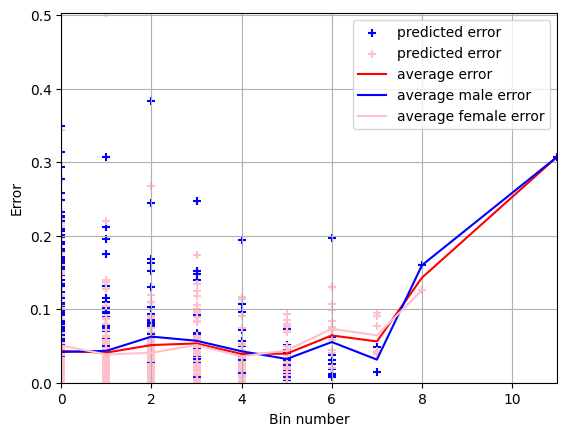

In [83]:
error_male = error_df.loc[error_df["gender"] == 1.0]
error_female = error_df.loc[error_df["gender"] == 0.0]
plt.scatter(x=error_male['bin'],y=error_male['error'], marker='+', label="predicted error", c='blue')
plt.scatter(x=error_female['bin'],y=error_female['error'], marker='+', label="predicted error", c='pink')
plt.plot(mae, color='r', label="average error")
plt.plot(mae_male['bin'],mae_male['error'], color='b', label="average male error")
plt.plot(mae_female['bin'],mae_female['error'], color='pink', label="average female error")
plt.xlabel("Bin number")
plt.ylabel("Error")
plt.xlim((0,max(error_df['bin'])))
plt.ylim((0,max(error_df['error'])))
plt.grid()
plt.legend()
plt.show()

## Regression for each category

In [70]:
def stratified_sample(df, max_per_bin=20, seed=42):
    return (
        df.groupby("bin", group_keys=False)
          .apply(lambda g: g.sample(min(len(g), max_per_bin),
                                    random_state=seed))
          .reset_index(drop=True)
    )

In [71]:
results_male_hair_b = results_male.loc[results_male["hair_b"] >= 0.1]
results_male_hat_b = results_male.loc[(results_male["hat_b"] >= 0.1) & (results_male["hair_b"] < 0.1)]
results_male_skin_b = results_male.loc[(results_male["error"] < 0.25) & (results_male["hair_b"] < 0.1) & (results_male["hat_b"] < 0.1)]

results_male_hair_b_strat = stratified_sample(results_male_hair_b)
results_male_hat_b_strat = stratified_sample(results_male_hat_b)
results_male_skin_b_strat = stratified_sample(results_male_skin_b)

print(results_male_hair_b_strat.shape,results_male_hat_b_strat.shape,results_male_skin_b_strat.shape)

(171, 11) (150, 11) (129, 11)


In [72]:
results_male_hair_s = results_male.loc[results_male["hair_s"] >= 0.1]
results_male_hat_s = results_male.loc[(results_male["hat_s"] >= 0.1) & (results_male["hair_s"] < 0.1)]
results_male_skin_s = results_male.loc[(results_male["error"] < 0.25) & (results_male["hair_s"] < 0.1) & (results_male["hat_s"] < 0.1)]

results_male_hair_s_strat = stratified_sample(results_male_hair_s)
results_male_hat_s_strat = stratified_sample(results_male_hat_s)
results_male_skin_s_strat = stratified_sample(results_male_skin_s)

print(results_male_hair_s_strat.shape,results_male_hat_s_strat.shape,results_male_skin_s_strat.shape)

(171, 11) (156, 11) (105, 11)


In [73]:
results_female_hair_b = results_female.loc[results_female["hair_b"] >= 0.1]
results_female_hat_b = results_female.loc[(results_female["hat_b"] >= 0.1) & (results_female["hair_b"] < 0.1)]
results_female_skin_b = results_female.loc[(results_female["error"] < 0.25) & (results_female["hair_b"] < 0.1) & (results_female["hat_b"] < 0.1)]

results_female_hair_b_strat = stratified_sample(results_female_hair_b)
results_female_hat_b_strat = stratified_sample(results_female_hat_b)
results_female_skin_b_strat = stratified_sample(results_female_skin_b)

print(results_female_hair_b_strat.shape,results_female_hat_b_strat.shape,results_female_skin_b_strat.shape)

(181, 11) (46, 11) (114, 11)


In [74]:
results_female_hair_s = results_female.loc[results_female["hair_s"] >= 0.1]
results_female_hat_s = results_female.loc[(results_female["hat_s"] >= 0.1) & (results_female["hair_s"] < 0.1)]
results_female_skin_s = results_female.loc[(results_female["error"] < 0.25) & (results_female["hair_s"] < 0.1) & (results_female["hat_s"] < 0.1)]

results_female_hair_s_strat = stratified_sample(results_female_hair_s)
results_female_hat_s_strat = stratified_sample(results_female_hat_s)
results_female_skin_s_strat = stratified_sample(results_female_skin_s)

print(results_female_hair_s_strat.shape,results_female_hat_s_strat.shape,results_female_skin_s_strat.shape)

(181, 11) (106, 11) (98, 11)


In [ ]:
from sklearn.linear_model import LinearRegression

def coeff_reg (df,score):
    X = np.array(df[score]).reshape(-1,1)
    y = np.array(df['target']).reshape(-1,1)
    reg = LinearRegression().fit(X, y)
    
    return reg.coef_, reg.intercept_

coeff_hair_M_b, intercept_hair_M_b = coeff_reg(results_male_hair_b_strat,"score_b")
print("Reg Hair M Bi")
print(coeff_hair_M_b, intercept_hair_M_b)

coeff_hat_M_b, intercept_hat_M_b = coeff_reg(results_male_hat_b_strat,"score_b")
print("Reg Hat M Bi")
print(coeff_hat_M_b, intercept_hat_M_b)

coeff_skin_M_b, intercept_skin_M_b = coeff_reg(results_male_skin_b_strat,"score_b")
print("Reg Base M Bi")
print(coeff_skin_M_b, intercept_skin_M_b)

coeff_hair_M_s, intercept_hair_M_s = coeff_reg(results_male_hair_s_strat,"score_s")
print("Reg Hair M Sf")
print(coeff_hair_M_s, intercept_hair_M_s)

coeff_hat_M_s, intercept_hat_M_s = coeff_reg(results_male_hat_s_strat,"score_s")
print("Reg Hat M Sf")
print(coeff_hat_M_s, intercept_hat_M_s)

coeff_skin_M_s, intercept_skin_M_s = coeff_reg(results_male_skin_s_strat,"score_s")
print("Reg Base M Sf")
print(coeff_skin_M_s, intercept_skin_M_s)


coeff_hair_F_b, intercept_hair_F_b = coeff_reg(results_female_hair_b_strat,"score_b")
print("Reg Hair F Bi")
print(coeff_hair_F_b, intercept_hair_F_b)

coeff_hat_F_b, intercept_hat_F_b = coeff_reg(results_female_hat_b_strat,"score_b")
print("Reg Hat F Bi")
print(coeff_hat_F_b, intercept_hat_F_b)

coeff_skin_F_b, intercept_skin_F_b = coeff_reg(results_female_skin_b_strat,"score_b")
print("Reg Base F Bi")
print(coeff_skin_F_b, intercept_skin_F_b)

coeff_hair_F_s, intercept_hair_F_s = coeff_reg(results_female_hair_s_strat,"score_s")
print("Reg Hair F Sf")
print(coeff_hair_F_s, intercept_hair_F_s)

coeff_hat_F_s, intercept_hat_F_s = coeff_reg(results_female_hat_s_strat,"score_s")
print("Reg Hat F Sf")
print(coeff_hat_F_s, intercept_hat_F_s)

coeff_skin_F_s, intercept_skin_F_s = coeff_reg(results_female_skin_s_strat,"score_s")
print("Reg Base F Sf")
print(coeff_skin_F_s, intercept_skin_F_s)

Reg Hair M Bi
[[0.63390033]] [0.0699488]
Reg Hat M Bi
[[0.49636345]] [0.10498165]
Reg Base M Bi
[[0.86657657]] [0.01500669]
Reg Hair M Sf
[[0.10190683]] [0.08712376]
Reg Hat M Sf
[[-0.05154064]] [0.16528579]
Reg Base M Sf
[[0.2650111]] [0.02064879]
Reg Hair F Bi
[[0.86728122]] [0.03612429]
Reg Hat F Bi
[[0.78097967]] [0.06469506]
Reg Base F Bi
[[0.8116649]] [0.03644012]
Reg Hair F Sf
[[0.47329155]] [0.08129084]
Reg Hat F Sf
[[-0.05572471]] [0.17991516]
Reg Base F Sf
[[0.49646234]] [0.03736469]


In [77]:
F_WEIGHTS = {"hair_bi": [coeff_hair_F_b.item(),intercept_hair_F_b.item()], "hat_bi": [coeff_hat_F_b.item(),intercept_hat_F_b.item()], "other_bi": [coeff_skin_F_b.item(),intercept_skin_F_b.item()],
             "hair_sf": [coeff_hair_F_s.item(),intercept_hair_F_s.item()], "hat_sf": [coeff_hat_F_s.item(),intercept_hat_F_s.item()], "other_sf": [coeff_skin_F_s.item(),intercept_skin_F_s.item()]}
M_WEIGHTS = {"hair_bi": [coeff_hair_M_b.item(),intercept_hair_M_b.item()], "hat_bi": [coeff_hat_M_b.item(),intercept_hat_M_b.item()], "other_bi": [coeff_skin_M_b.item(),intercept_skin_M_b.item()],
             "hair_sf": [coeff_hair_M_s.item(),intercept_hair_M_s.item()], "hat_sf": [coeff_hat_M_s.item(),intercept_hat_M_s.item()], "other_sf": [coeff_skin_M_s.item(),intercept_skin_M_s.item()]}

In [78]:
weights = {
    "female": F_WEIGHTS,
    "male": M_WEIGHTS
}

with open("weights.json", "w", encoding="utf-8") as f:
    json.dump(weights, f, indent=4)

## Nelder-Mead optimization

In [61]:
from scipy.optimize import minimize

GENDER_FEMALE = 0.0
GENDER_MALE = 1.0

OCC_BINS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 1.01]

# Distribution officielle Telecom (= ce que IDEMIA reweighte pour scoring brief)
TEST_DISTRIBUTIONS = {
    "brief":  np.array([0.18, 0.16, 0.14, 0.15, 0.26, 0.15, 0.003]),
    "spread": np.array([0.10, 0.15, 0.15, 0.15, 0.25, 0.18, 0.020]),
    "heavy":  np.array([0.05, 0.10, 0.10, 0.15, 0.25, 0.30, 0.050]),
}

def predict_v_features(df: pd.DataFrame, F_weights: dict, M_weights: dict,
                       gender_col: str = "gender") -> np.ndarray:
    """Calcule la prediction v_features pour chaque ligne du DataFrame.

    Formule (per gender) :
        pred = w_hair_bi * hair_bi_in_mask
             + w_hat_bi  * hat_bi_in_mask
             + w_other_bi * other_bi_in_mask
             + w_hair_sf * hair_sf_in_mask
             + w_hat_sf  * hat_sf_in_mask
             + w_other_bg_sf * (other_sf_in_mask + bg_sf_in_mask)

    Note : on additionne bg_sf et other_sf en un seul terme "other_bg_sf"
    (asymetrie BiSeNet vs SegFormer : bg_bi traite comme visible, bg_sf comme occlusion).

    Returns:
        np.array de predictions clip dans [0, 1].
    """
    hair_bi = df.hair_b.values
    hat_bi = df.hat_b.values
    other_bi = df.other_b.values
    hair_sf = df.hair_s.values
    hat_sf = df.hat_s.values
    other_bg_sf = df.other_s.values
    is_F = (df[gender_col].values == GENDER_FEMALE)

    pred_F = (F_weights["hair_bi"] * hair_bi + F_weights["hat_bi"] * hat_bi +
              F_weights["other_bi"] * other_bi + F_weights["hair_sf"] * hair_sf +
              F_weights["hat_sf"] * hat_sf + F_weights["other_sf"] * other_bg_sf)
    pred_M = (M_weights["hair_bi"] * hair_bi + M_weights["hat_bi"] * hat_bi +
              M_weights["other_bi"] * other_bi + M_weights["hair_sf"] * hair_sf +
              M_weights["hat_sf"] * hat_sf + M_weights["other_sf"] * other_bg_sf)

    return np.clip(np.where(is_F, pred_F, pred_M), 0, 1)

def _sample_weight(gt: np.ndarray) -> np.ndarray:
    """Poids par echantillon : w_i = 1/30 + GT_i (cf. brief IDEMIA)."""
    return 1.0 / 30.0 + gt


def reweighted_score(df: pd.DataFrame, target_bin_probs: np.ndarray,
                     pred_col: str = "pred", gt_col: str = "target",
                     gender_col: str = "gender", bins: list = OCC_BINS) -> dict:
    """Score si val suivait la distribution target_bin_probs (= brief Telecom).

    Reweighte chaque sample par m_b = q_b / p_b ou :
        p_b = fraction empirique val dans bin b (per gender)
        q_b = fraction cible dans bin b (= TEST_DISTRIBUTIONS[name])

    Score = (err_F + err_M) / 2 + |err_F - err_M|
    """
    q = np.asarray(target_bin_probs, dtype=np.float64)
    q = q / q.sum() if q.sum() > 0 else q

    pred = df[pred_col].to_numpy(dtype=np.float64)
    gt = df[gt_col].to_numpy(dtype=np.float64)
    gender = df[gender_col].to_numpy(dtype=np.float64)
    w = _sample_weight(gt)
    sqerr = (pred - gt) ** 2
    bin_idx = np.clip(np.searchsorted(bins, gt, side="right") - 1, 0, len(bins) - 2)

    err_per_gender = {}
    n_per_gender = {}
    for gval, glbl in ((GENDER_FEMALE, "F"), (GENDER_MALE, "M")):
        mask_g = gender == gval
        n_per_gender[glbl] = int(mask_g.sum())
        if mask_g.sum() == 0:
            err_per_gender[glbl] = float("nan")
            continue
        bins_present = np.bincount(bin_idx[mask_g], minlength=len(bins) - 1)
        p = bins_present / mask_g.sum()
        q_eff = np.where(p > 0, q, 0.0)
        if q_eff.sum() == 0:
            err_per_gender[glbl] = float("nan")
            continue
        q_eff = q_eff / q_eff.sum()
        m_per_bin = np.where(p > 0, q_eff / np.where(p > 0, p, 1.0), 0.0)
        m = m_per_bin[bin_idx]
        num = (m * w * sqerr)[mask_g].sum()
        den = (m * w)[mask_g].sum()
        err_per_gender[glbl] = float(num / den) if den > 0 else float("nan")

    err_F = err_per_gender["F"]
    err_M = err_per_gender["M"]
    n_F = n_per_gender["F"]
    n_M = n_per_gender["M"]
    if np.isnan(err_F) or np.isnan(err_M):
        return {"err_F": err_F, "err_M": err_M, "mean_err": float("nan"),
                "gap": float("nan"), "score": float("nan"), "n_F": n_F, "n_M": n_M}
    mean_err = (n_F * err_F + n_M * err_M) / (n_F + n_M)
    gap = abs(err_F - err_M)
    score = (err_F + err_M) / 2.0 + gap  # < METRIQUE OFFICIELLE >
    return {"err_F": err_F, "err_M": err_M, "mean_err": mean_err,
            "gap": gap, "score": score, "n_F": n_F, "n_M": n_M}

def objective_brief(params: np.ndarray, df: pd.DataFrame) -> float:
    """Fonction objectif passee a scipy.optimize.minimize.

    Unpack les 12 params en F_weights et M_weights, calcule la prediction
    v_features, calcule le score brief reweighted, retourne ce score.

    L'optimizer cherche le minimum -> il trouve les coefficients qui minimisent
    le score officiel sur val.

    Args:
        params: array de 12 floats. Layout :
                params[0:6]  = F_weights : hair_bi, hat_bi, other_bi, hair_sf, hat_sf, other_bg_sf
                params[6:12] = M_weights : idem
        df: DataFrame val_features.csv avec colonne 'pred' preallouee

    Returns:
        score brief reweighted (float, on cherche son minimum)
    """
    F_w = {"hair_bi": params[0], "hat_bi": params[1], "other_bi": params[2],
           "hair_sf": params[3], "hat_sf": params[4], "other_sf": params[5]}
    M_w = {"hair_bi": params[6], "hat_bi": params[7], "other_bi": params[8],
           "hair_sf": params[9], "hat_sf": params[10], "other_sf": params[11]}
    df.loc[:, "pred"] = predict_v_features(df, F_w, M_w)
    return reweighted_score(df, TEST_DISTRIBUTIONS["brief"])["score"]

def optim_nelder_mead(df):

    df["pred"] = 0.0

    x0 = np.array([
        0.48, 0.48, 0.48,   0.66, 0.66, 0.66,    # F
        0.36, 0.36, 0.36,   0.54, 0.54, 0.54,    # M
    ])
    # === Optimization Nelder-Mead ===
    res = minimize(
        objective_brief, x0, args=(df,),
        method="Nelder-Mead",
        options={"maxiter": 5000, "xatol": 1e-5, "fatol": 1e-7, "disp": True},
    )

    # === Save coefficients ===
    F_w = {"hair_bi": float(res.x[0]),  "hat_bi": float(res.x[1]),  "other_bi": float(res.x[2]),
           "hair_sf": float(res.x[3]),  "hat_sf": float(res.x[4]),  "other_sf": float(res.x[5])}
    M_w = {"hair_bi": float(res.x[6]),  "hat_bi": float(res.x[7]),  "other_bi": float(res.x[8]),
           "hair_sf": float(res.x[9]),  "hat_sf": float(res.x[10]), "other_sf": float(res.x[11])}
    coefficients = {"female": F_w, "male": M_w}
    with open("coeffs.json", "w", encoding="utf-8") as f:
        json.dump(coefficients, f, indent=4)
    
    #Print results
    print("Coefficients found :")
    print(f"{'feature':<15} {'F':>10} {'M':>10}")
    for k in ["hair_bi", "hat_bi", "other_bi", "hair_sf", "hat_sf", "other_sf"]:
        print(f"{k:<15} {F_w[k]:>+10.4f} {M_w[k]:>+10.4f}")

    return None

optim_nelder_mead(results_df)

Optimization terminated successfully.
         Current function value: 0.004920
         Iterations: 2926
         Function evaluations: 4006
Coefficients found :
feature                  F          M
hair_bi            +0.4786    +0.4556
hat_bi             +0.6222    +0.3835
other_bi           +0.4245    +0.3483
hair_sf            +0.7565    +0.6052
hat_sf             +0.6777    +0.6505
other_sf           +0.4855    +0.1240
